# Office Presence Sub-Model (J-7)

Predict `office_present` 7 days ahead using only features available at J-8.
This feeds the main cantine model as its most important predictor.

**Target**: `office_present`
**Horizon**: 7 days (shift >= 7 for all features)
**No cantine data** (future leakage)

In [1]:
import os, sys, warnings, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb
import optuna
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
HORIZON = 7
np.random.seed(SEED)

REPO_ROOT = Path().resolve().parent
PROC_DIR  = REPO_ROOT / 'data' / 'processed'
FIG_DIR   = REPO_ROOT / 'reports' / 'figures'
MODEL_DIR = REPO_ROOT / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_DIR / 'real_clean.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['day_of_month'] = df['Date'].dt.day
df['month_n']      = df['Date'].dt.month
df['dow']          = df['Date'].dt.dayofweek
df['day_of_year']  = df['Date'].dt.dayofyear
df['days_in_month']= df['Date'].dt.days_in_month
df['year_n']       = df['Date'].dt.year

print(f"Loaded {len(df)} rows  |  {df['Date'].min().date()} to {df['Date'].max().date()}")

Loaded 605 rows  |  2022-05-05 to 2024-12-31


c:\Users\Drache Shop\anaconda3\envs\DM_ENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Engineering (J-7 safe only)

All features use information available at J-8 at latest. No cantine data, no menu features.

In [2]:
min_date = df['Date'].min()

# --- Calendar features -------------------------------------------------------
df['trend_days']    = (df['Date'] - min_date).dt.days
df['month_progress']= df['day_of_month'] / df['days_in_month']
df['week_of_month'] = (df['day_of_month'] - 1) // 7 + 1
df['is_week1_month']= (df['week_of_month'] == 1).astype(int)
df['is_week4_month']= (df['week_of_month'] >= 4).astype(int)
df['quarter']       = df['Date'].dt.quarter
df['week_of_year']  = df['Date'].dt.isocalendar().week.astype(int)

# DOW dummies (Algerian: Sun=6 work, Mon=0, Tue=1, Wed=2, Thu=3 work; Fri=4/Sat=5 weekend)
df['is_weekend'] = df['dow'].isin([4, 5]).astype(int)
df['is_sun']     = (df['dow'] == 6).astype(int)
df['is_mon']     = (df['dow'] == 0).astype(int)
df['is_tue']     = (df['dow'] == 1).astype(int)
df['is_wed']     = (df['dow'] == 2).astype(int)
df['is_thu']     = (df['dow'] == 3).astype(int)

# Fourier annual (k=1,2,3)
doy = df['day_of_year'].astype(float)
for k in range(1, 4):
    df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
    df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

# Fourier weekly (5-day Algerian week)
df['sin_week'] = np.sin(2 * np.pi * df['dow'] / 5)
df['cos_week'] = np.cos(2 * np.pi * df['dow'] / 5)

print("Calendar features done.")

Calendar features done.


In [3]:
# --- Holiday features --------------------------------------------------------
import holidays as hol

fr_holidays = hol.France(years=range(2022, 2026))
fr_set = set(pd.Timestamp(d) for d, _ in fr_holidays.items())
df['is_fr_holiday'] = df['Date'].isin(fr_set).astype(int)

islamic_dates = pd.to_datetime([
    '2022-05-02','2023-04-21','2024-04-10','2025-03-30',
    '2022-07-09','2023-06-28','2024-06-16','2025-06-07',
    '2022-10-08','2023-09-27','2024-09-15','2025-09-05',
    '2022-07-30','2023-07-19','2024-07-07','2025-06-26',
    '2022-08-08','2023-07-28','2024-07-16','2025-07-05',
])
df['is_islamic_holiday'] = df['Date'].isin(islamic_dates).astype(int)

algerian_dates = pd.to_datetime([
    '2022-07-05','2023-07-05','2024-07-05','2025-07-05',
    '2022-11-01','2023-11-01','2024-11-01','2025-11-01',
])
df['is_algerian_holiday'] = df['Date'].isin(algerian_dates).astype(int)

df['is_any_holiday'] = ((df['is_fr_holiday'] | df['is_islamic_holiday'] | df['is_algerian_holiday'])).astype(int)

# days_to_next_holiday / since_last (capped 14)
holiday_dates = df.loc[df['is_any_holiday']==1, 'Date'].values
dt_next = np.full(len(df), 14.0)
dt_prev = np.full(len(df), 14.0)
for i, d in enumerate(df['Date'].values):
    future = holiday_dates[holiday_dates >= d]
    if len(future) > 0:
        dt_next[i] = min((future[0] - d) / np.timedelta64(1,'D'), 14.0)
    past = holiday_dates[holiday_dates <= d]
    if len(past) > 0:
        dt_prev[i] = min((d - past[-1]) / np.timedelta64(1,'D'), 14.0)
df['days_to_next_holiday'] = dt_next.astype(int)
df['days_since_last_holiday'] = dt_prev.astype(int)
df['near_holiday'] = ((df['days_to_next_holiday'] <= 2) | (df['days_since_last_holiday'] <= 2)).astype(int)

# Ramadan
ramadan_periods = [('2022-04-02','2022-05-01'),('2023-03-22','2023-04-20'),
                   ('2024-03-11','2024-04-09'),('2025-02-28','2025-03-29')]
df['is_ramadan'] = 0
df['ramadan_day'] = 0
for s_str, e_str in ramadan_periods:
    s, e = pd.Timestamp(s_str), pd.Timestamp(e_str)
    mask = (df['Date'] >= s) & (df['Date'] <= e)
    df.loc[mask, 'is_ramadan'] = 1
    df.loc[mask, 'ramadan_day'] = (df.loc[mask, 'Date'] - s).dt.days + 1

# Seasonal flags
df['is_august']    = (df['month_n'] == 8).astype(int)
df['is_july']      = (df['month_n'] == 7).astype(int)
df['is_summer']    = df['month_n'].isin([6,7,8]).astype(int)
df['is_yearend']   = ((df['month_n'] == 12) & (df['day_of_month'] >= 22)).astype(int)
df['is_jan_start'] = ((df['month_n'] == 1) & (df['day_of_month'] <= 10)).astype(int)
df['is_payday1']   = df['day_of_month'].isin(range(1,6)).astype(int)
df['is_payday2']   = df['day_of_month'].isin(range(14,17)).astype(int)
df['is_payday3']   = (df['day_of_month'] >= 26).astype(int)

print(f"Holiday features done. is_any_holiday=1: {df['is_any_holiday'].sum()}, is_ramadan=1: {df['is_ramadan'].sum()}")

Holiday features done. is_any_holiday=1: 21, is_ramadan=1: 2


In [4]:
# --- Office presence lag/rolling features (all shift >= 7) --------------------
for lag in [7, 14, 21, 28]:
    df[f'op_lag_{lag}'] = df['office_present'].shift(lag)

base = df['office_present'].shift(7)
for w in [28, 56]:
    df[f'op_roll_mean_{w}'] = base.rolling(w).mean()
    df[f'op_roll_std_{w}']  = base.rolling(w).std()
    df[f'op_roll_max_{w}']  = base.rolling(w).max()
    df[f'op_roll_min_{w}']  = base.rolling(w).min()

# --- YoY office features (shift >= 7) -----------------------------------------
df['op_yoy_52w']  = df['office_present'].shift(364)
yoy_vals = []
for i in range(len(df)):
    start = max(0, i - 364 - 10)
    end   = min(len(df), i - 364 + 11)
    if end - start < 3:
        yoy_vals.append(np.nan)
    else:
        yoy_vals.append(np.median(df.iloc[start:end]['office_present'].values))
df['op_yoy_smooth'] = yoy_vals
df['op_yoy_ratio']  = df['office_present'] / df['op_yoy_52w'].replace(0, np.nan)

print("Lag/rolling/YoY office features done.")

Lag/rolling/YoY office features done.


In [5]:
# --- DOW conditional stats (training-only, no leakage) -----------------------
op_dow_mean_vals  = np.full(len(df), np.nan)
op_dow_std_vals   = np.full(len(df), np.nan)
op_month_mean_vals= np.full(len(df), np.nan)
op_dm_mean_vals   = np.full(len(df), np.nan)

for i in range(len(df)):
    d = df.iloc[i]['dow']
    m = df.iloc[i]['month_n']
    if i < 14:
        continue
    past = df.iloc[:i]
    d_sub = past[past['dow'] == d]['office_present'].dropna()
    if len(d_sub) >= 5:
        op_dow_mean_vals[i] = d_sub.mean()
        op_dow_std_vals[i]  = d_sub.std()
    m_sub = past[past['month_n'] == m]['office_present'].dropna()
    if len(m_sub) >= 5:
        op_month_mean_vals[i] = m_sub.mean()
    dm_sub = past[(past['dow'] == d) & (past['month_n'] == m)]['office_present'].dropna()
    if len(dm_sub) >= 2:
        op_dm_mean_vals[i] = dm_sub.mean()

df['op_dow_mean']   = op_dow_mean_vals
df['op_dow_std']    = op_dow_std_vals
df['op_month_mean'] = op_month_mean_vals
df['op_dm_mean']    = op_dm_mean_vals
df['op_dow_zscore'] = (df['office_present'] - df['op_dow_mean']) / (df['op_dow_std'] + 1)

# Diff/pct from lag-7
df['op_diff_7d'] = df['office_present'] - df['op_lag_7']
df['op_pct_7d']  = df['op_diff_7d'] / (df['op_lag_7'] + 1)

# DOW x office interactions
for day, col in [('sun','is_sun'),('mon','is_mon'),('tue','is_tue'),('wed','is_wed'),('thu','is_thu')]:
    df[f'op_x_{day}'] = df['office_present'] * df[col]

df['op_x_summer']       = df['office_present'] * df['is_summer']
df['op_x_ramadan']      = df['office_present'] * df['is_ramadan']
df['op_x_near_holiday'] = df['office_present'] * df['near_holiday']

print("DOW conditional stats done.")

DOW conditional stats done.


In [6]:
# Define feature set: ONLY J-7 safe features
TARGET = 'office_present'
exclude_cols = {TARGET, 'Date', 'employees_count', 'ratio', 'ratio_capped',
                'entrees', 'plat_principal_1', 'plat_principal_2',
                'weather_conditions', 'precipitation_type',
                'temperature', 'temperature_felt', 'precipitation_mm',
                'wind_gust_kmh', 'wind_speed_kmh', 'cloud_cover_pct',
                'is_working_day'}

feature_cols = [c for c in df.columns if c not in exclude_cols
                and pd.api.types.is_numeric_dtype(df[c])]
print(f"Features: {len(feature_cols)}")
print(f"Target: {TARGET}")
for f in feature_cols:
    nn = df[f].notna().sum()
    if nn < len(df):
        print(f"  warm-up: {f:35s}  first_valid_row={df[f].first_valid_index():4d}  NaN={len(df)-nn}")

Features: 74
Target: office_present
  warm-up: op_lag_7                             first_valid_row=   7  NaN=7
  warm-up: op_lag_14                            first_valid_row=  14  NaN=14
  warm-up: op_lag_21                            first_valid_row=  21  NaN=21
  warm-up: op_lag_28                            first_valid_row=  28  NaN=28
  warm-up: op_roll_mean_28                      first_valid_row=  34  NaN=34
  warm-up: op_roll_std_28                       first_valid_row=  34  NaN=34
  warm-up: op_roll_max_28                       first_valid_row=  34  NaN=34
  warm-up: op_roll_min_28                       first_valid_row=  34  NaN=34
  warm-up: op_roll_mean_56                      first_valid_row=  62  NaN=62
  warm-up: op_roll_std_56                       first_valid_row=  62  NaN=62
  warm-up: op_roll_max_56                       first_valid_row=  62  NaN=62
  warm-up: op_roll_min_56                       first_valid_row=  62  NaN=62
  warm-up: op_yoy_52w                    

## Baselines

We test 4 simple baselines before the LGB model:

1. **DOW-x-Month mean** (historical mean for that DOW+month combo)
2. **Same-day-last-week** (lag-7)
3. **Persistence brute** (lag-8, raw — no weekday alignment)
4. **Simple regression** (trend + DOW dummies + month dummies)

In [7]:
def asymmetric_cost(y_true, y_pred):
    # 2x penalty for underestimation, 1x for overestimation.
    diff = y_true - y_pred
    return np.mean(np.where(diff > 0, 2 * diff, -diff))

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs(y_true - y_pred) / (y_true + 1)) * 100
    ac   = asymmetric_cost(y_true, y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    print(f"  {label:30s}  RMSE={rmse:7.2f}  MAE={mae:6.2f}  MAPE={mape:5.1f}%  AsymCost={ac:7.2f}  R2={r2:.4f}")
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'asym': ac, 'r2': r2}

# --- Baseline 1: DOW x Month historical mean (training-only, no leakage) -----
def baseline_dow_month(train_df, test_df, target):
    gm = train_df[target].mean()
    enc = train_df.groupby(['dow','month_n'])[target].agg(['mean','count'])
    smooth = (enc['mean'] * enc['count'] + 5 * gm) / (enc['count'] + 5)
    map_ = smooth.to_dict()
    return test_df.apply(lambda r: map_.get((r['dow'], r['month_n']), gm), axis=1).values

# --- Baseline 2: lag-7 (same day last week) -----------------------------------
def baseline_lag7(df, target):
    return df[target].shift(7).values

# --- Baseline 3: lag-8 (raw persistence, no weekday alignment) ----------------
def baseline_lag8(df, target):
    return df[target].shift(8).values

# --- Baseline 4: simple regression (trend + DOW + month dummies) ---------------
from sklearn.linear_model import Ridge

def baseline_ridge(train_df, test_df, target):
    dows = [c for c in train_df.columns if c.startswith('is_') and c in ['is_sun','is_mon','is_tue','is_wed','is_thu']]
    months = pd.get_dummies(train_df['month_n'], prefix='m', drop_first=True)
    X_tr = pd.concat([train_df[['trend_days']].reset_index(drop=True),
                      train_df[dows].reset_index(drop=True),
                      months.reset_index(drop=True)], axis=1)
    y_tr = train_df[target].values
    months_te = pd.get_dummies(test_df['month_n'], prefix='m', drop_first=True)
    # Align columns
    months_te = months_te.reindex(columns=months.columns, fill_value=0)
    X_te = pd.concat([test_df[['trend_days']].reset_index(drop=True),
                      test_df[dows].reset_index(drop=True),
                      months_te.reset_index(drop=True)], axis=1)
    # Align columns
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)
    m = Ridge(alpha=1.0, random_state=SEED)
    m.fit(X_tr, y_tr)
    return m.predict(X_te)

## Cross-Validation: TimeSeriesSplit (5 folds, gap=7)

In [8]:
n = len(df)
test_size = max(40, n // 8)
print(f"n={n}, test_size={test_size}, n_splits=5, gap=7")

tscv = TimeSeriesSplit(n_splits=5, gap=7, test_size=test_size)

all_oof    = np.full(len(df), np.nan)
fold_results = []

def eval_safe(y_true, y_pred, label=''):
    # Drop pairs where either is NaN
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        print(f"  {label:30s}  SKIPPED (no valid pairs)")
        return None
    return evaluate(y_true[mask], y_pred[mask], label)

for fold_i, (tr_idx, te_idx) in enumerate(tscv.split(df)):
    tr = df.iloc[tr_idx].copy().reset_index(drop=True)
    te = df.iloc[te_idx].copy().reset_index(drop=True)

    y_tr = tr[TARGET].values
    y_te = te[TARGET].values

    # LightGBM handles NaN natively, so pass all rows
    feat_tr_all = tr[feature_cols].copy()
    feat_te_all = te[feature_cols].copy()

    # Drop only rows where ALL features are NaN (warm-up)
    feat_tr_clean = feat_tr_all.dropna(how='all')
    y_tr_clean    = y_tr[feat_tr_all.dropna(how='all').index]

    # Baselines from full series (correct alignment via df index)
    y_lag7 = df.iloc[te_idx][TARGET].shift(7).values
    y_lag8 = df.iloc[te_idx][TARGET].shift(8).values
    y_dm   = baseline_dow_month(tr, te, TARGET)
    y_ridge= baseline_ridge(tr, te, TARGET)

    # Valid mask for test: features non-NaN AND target non-NaN
    valid_te = feat_te_all.notna().all(axis=1)
    vt = valid_te.values

    print(f"\nFold {fold_i}: train={len(tr)} clean={len(feat_tr_clean)} test={len(te)}  "
          f"dates={df.iloc[te_idx[0]]['Date'].date()} to {df.iloc[te_idx[-1]]['Date'].date()}")

    if vt.sum() > 0:
        print("  Baselines:")
        eval_safe(y_te[vt], y_lag7[vt],   'lag-7 (same day last week)')
        eval_safe(y_te[vt], y_lag8[vt],   'lag-8 (raw persistence)')
        eval_safe(y_te[vt], y_dm[vt],     'DOW x Month mean')
        eval_safe(y_te[vt], y_ridge[vt],  'Ridge (trend + DOW + month)')

    # --- LightGBM with Optuna ---
    if len(feat_tr_clean) < 30:
        print(f"  SKIPPED Optuna (only {len(feat_tr_clean)} clean train rows)")
        continue

    def objective(trial):
        params = {
            'objective': 'regression', 'metric': 'rmse', 'verbosity': -1,
            'seed': SEED, 'n_jobs': -1,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'max_depth': trial.suggest_int('max_depth', 5, 8),
            'min_child_samples': trial.suggest_int('min_child_samples', 8, 20),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        n_tr = int(len(feat_tr_clean) * 0.85)
        X_tr_opt = feat_tr_clean.iloc[:n_tr]
        y_tr_opt = y_tr_clean[:n_tr]
        X_va_opt = feat_tr_clean.iloc[n_tr:]
        y_va_opt = y_tr_clean[n_tr:]

        dtrain = lgb.Dataset(X_tr_opt, label=y_tr_opt)
        dval   = lgb.Dataset(X_va_opt, label=y_va_opt, reference=dtrain)
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        model = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dval], callbacks=callbacks)
        pred = model.predict(X_va_opt)
        return np.sqrt(mean_squared_error(y_va_opt, pred))

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=20, timeout=600)
    best_params = study.best_params
    best_params['objective'] = 'regression'
    best_params['metric'] = 'rmse'
    best_params['verbosity'] = -1
    best_params['seed'] = SEED
    best_params['n_jobs'] = -1

    print(f"  Optuna best RMSE: {study.best_value:.2f}")

    # --- Multi-seed ensemble ---------------------------------------------------
    trained_models = []
    seeds = [42, 7, 2024]
    fold_preds = np.full(len(te), np.nan)

    for s in seeds:
        p = best_params.copy()
        p['seed'] = s
        dtrain = lgb.Dataset(feat_tr_clean, label=y_tr_clean)
        # Use only valid test rows for early stopping
        feat_te_valid = feat_te_all[vt]
        y_te_valid    = y_te[vt]
        if len(feat_te_valid) == 0:
            fold_preds = np.full(len(te), np.nan)
            break
        dval   = lgb.Dataset(feat_te_valid, label=y_te_valid, reference=dtrain)
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        model = lgb.train(p, dtrain, num_boost_round=1000, valid_sets=[dval], callbacks=callbacks)
        pred  = model.predict(feat_te_all)
        if np.all(np.isnan(fold_preds)):
            fold_preds = pred
        else:
            fold_preds += pred

    fold_preds /= len(seeds)

    # Store OOF
    all_oof[te_idx] = fold_preds

    # Evaluate LGB ensemble
    if vt.sum() > 0:
        print("  LGB Ensemble:")
        res = eval_safe(y_te[vt], fold_preds[vt], f'Fold {fold_i} LGB')
        if res:
            fold_results.append(res)

    # Save feature importance from last fold
    if fold_i == 4:
        last_model = model
        last_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': last_model.feature_importance(importance_type='gain')
        }).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("OOF Results (all folds combined):")
valid_oof = ~np.isnan(all_oof)
if valid_oof.sum() > 0:
    y_all = df[TARGET].values
    eval_safe(y_all[valid_oof], all_oof[valid_oof], 'Full OOF LGB Ensemble')

n=605, test_size=75, n_splits=5, gap=7


[I 2026-09-01 09:53:55,216] A new study created in memory with name: no-name-be1d455d-c266-48b5-8a5c-ab3552270f33



Fold 0: train=223 clean=223 test=75  dates=2023-04-30 to 2023-08-27


[I 2026-09-01 09:53:55,414] Trial 0 finished with value: 24.28441421037125 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 122, 'max_depth': 7, 'min_child_samples': 15, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 24.28441421037125.
[I 2026-09-01 09:53:55,487] Trial 1 finished with value: 32.68998072796785 and parameters: {'learning_rate': 0.06054365855469246, 'num_leaves': 95, 'max_depth': 5, 'min_child_samples': 20, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 24.28441421037125.
[I 2026-09-01 09:53:55,706] Trial 2 finished with value: 33.95360833573768 and parameters: {'learning_rate': 0.024878734419814436, 'num_leaves': 74, 'max_depth': 6, 'min_child_samples': 11, 'subsample': 0.8447411578889518, 'colsample_bytre

  Optuna best RMSE: 18.12

Fold 1: train=298 clean=298 test=75  dates=2023-08-28 to 2023-12-12
  Baselines:
  lag-7 (same day last week)      RMSE=  36.23  MAE= 29.25  MAPE=  5.0%  AsymCost=  45.12  R2=-0.6584
  lag-8 (raw persistence)         RMSE=  36.28  MAE= 28.69  MAPE=  4.9%  AsymCost=  44.19  R2=-0.6631
  DOW x Month mean                RMSE=  62.28  MAE= 57.54  MAPE=  9.6%  AsymCost= 114.19  R2=-3.9009
  Ridge (trend + DOW + month)     RMSE=  30.37  MAE= 25.15  MAPE=  4.3%  AsymCost=  40.99  R2=-0.1650


...

  Optuna best RMSE: 6.36


[I 2026-09-01 09:54:18,163] A new study created in memory with name: no-name-16223bfb-7254-4ac2-923f-a08ee913d800


  LGB Ensemble:
  Fold 3 LGB                      RMSE=  10.94  MAE=  8.61  MAPE=  1.6%  AsymCost=  15.22  R2=0.9465

Fold 4: train=523 clean=523 test=75  dates=2024-09-18 to 2024-12-31
  Baselines:
  lag-7 (same day last week)      RMSE= 100.88  MAE= 63.74  MAPE= 12.9%  AsymCost=  93.62  R2=-1.1604
  lag-8 (raw persistence)         RMSE= 101.94  MAE= 63.76  MAPE= 13.1%  AsymCost=  93.22  R2=-1.1748
  DOW x Month mean                RMSE=  69.74  MAE= 54.45  MAPE= 10.7%  AsymCost=  93.68  R2=-0.1181
  Ridge (trend + DOW + month)     RMSE=  66.94  MAE= 38.01  MAPE=  8.3%  AsymCost=  48.30  R2=-0.0300


[I 2026-09-01 09:54:19,040] Trial 0 finished with value: 11.937098718375335 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 122, 'max_depth': 7, 'min_child_samples': 15, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 11.937098718375335.
[I 2026-09-01 09:54:19,563] Trial 1 finished with value: 13.541034393168516 and parameters: {'learning_rate': 0.06054365855469246, 'num_leaves': 95, 'max_depth': 5, 'min_child_samples': 20, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 11.937098718375335.
[I 2026-09-01 09:54:20,322] Trial 2 finished with value: 11.514601884884232 and parameters: {'learning_rate': 0.024878734419814436, 'num_leaves': 74, 'max_depth': 6, 'min_child_samples': 11, 'subsample': 0.8447411578889518, 'colsample_

  Optuna best RMSE: 9.38
  LGB Ensemble:
  Fold 4 LGB                      RMSE=  10.11  MAE=  7.90  MAPE=  1.4%  AsymCost=  15.04  R2=0.9765

OOF Results (all folds combined):
  Full OOF LGB Ensemble           RMSE=  11.82  MAE=  8.77  MAPE=  1.6%  AsymCost=  16.35  R2=0.9523


In [9]:
print("\nTop 15 Features by Gain:")
for i, row in last_importance.head(15).iterrows():
    print(f"  {last_importance.index.get_loc(i)+1:2d}. {row['feature']:35s}  gain={row['importance']:.0f}")


Top 15 Features by Gain:
   1. op_dow_zscore                        gain=3962334
   2. op_dow_mean                          gain=340675
   3. op_x_summer                          gain=116505
   4. op_diff_7d                           gain=114194
   5. op_pct_7d                            gain=95290
   6. op_dow_std                           gain=54180
   7. is_thu                               gain=22096
   8. op_x_thu                             gain=16583
   9. cos_year_2                           gain=15382
  10. sin_year_3                           gain=15177
  11. trend_days                           gain=12951
  12. op_roll_max_28                       gain=10776
  13. days_to_next_holiday                 gain=9416
  14. cos_week                             gain=9121
  15. op_dm_mean                           gain=8437


## Test Prediction (recursive, last 40 rows as held-out test)

Train: 565 rows  |  Test: 40 rows
Test period: 2024-11-06 to 2024-12-31


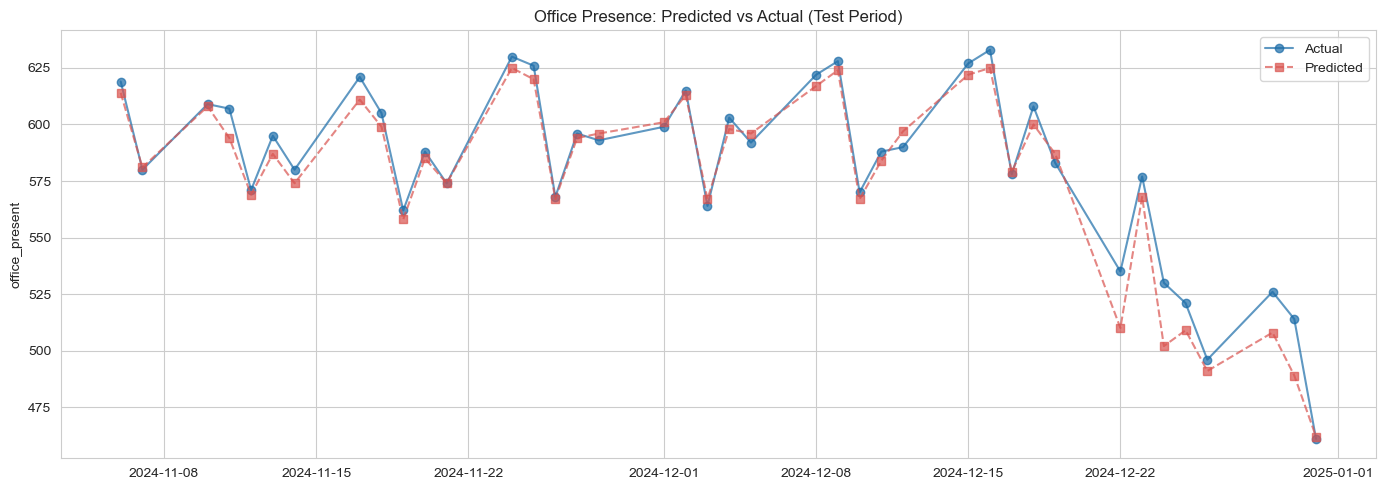


Test RMSE: 9.34  |  Test MAE: 6.60


In [10]:
# Use last 40 rows as test, rest as train
TEST_SIZE = 40
train_df = df.iloc[:-TEST_SIZE].copy()
test_df  = df.iloc[-TEST_SIZE:].copy().reset_index(drop=True)

print(f"Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")
print(f"Test period: {test_df['Date'].iloc[0].date()} to {test_df['Date'].iloc[-1].date()}")

# --- Recursive prediction for test set ----------------------------------------
# Seed: use last known office_present values from train tail
last_known = train_df['office_present'].values.copy()
preds = []

for i in range(TEST_SIZE):
    # Build feature vector for this test row
    row = test_df.iloc[i].copy()
    # Compute lags from known/predicted values
    all_vals = np.concatenate([last_known, preds])
    base_idx = len(last_known) + i

    # Lag features
    for lag in [7, 14, 21, 28]:
        idx = base_idx - lag
        if idx >= 0:
            row[f'op_lag_{lag}'] = all_vals[idx]
        else:
            row[f'op_lag_{lag}'] = np.nan

    # Rolling from lag-7 base
    base_lag7_idx = base_idx - 7
    if base_lag7_idx >= 0:
        window = all_vals[max(0, base_lag7_idx-27):base_lag7_idx+1]
        row['op_roll_mean_28'] = np.mean(window) if len(window) > 0 else np.nan
        row['op_roll_std_28']  = np.std(window) if len(window) > 1 else np.nan
        row['op_roll_max_28']  = np.max(window) if len(window) > 0 else np.nan
        row['op_roll_min_28']  = np.min(window) if len(window) > 0 else np.nan
        window56 = all_vals[max(0, base_lag7_idx-55):base_lag7_idx+1]
        row['op_roll_mean_56'] = np.mean(window56) if len(window56) > 0 else np.nan

    # Diff/pct from lag-7
    if pd.notna(row.get('op_lag_7', np.nan)):
        row['op_diff_7d'] = row.get('office_present', np.nan) - row['op_lag_7'] if 'office_present' in row.index else np.nan
        row['op_pct_7d']  = row['op_diff_7d'] / (row['op_lag_7'] + 1)

    # DOW conditional stats from train
    d, m = row['dow'], row['month_n']
    d_sub = train_df[train_df['dow'] == d]['office_present']
    m_sub = train_df[train_df['month_n'] == m]['office_present']
    row['op_dow_mean'] = d_sub.mean() if len(d_sub) >= 5 else train_df['office_present'].mean()
    row['op_dow_std']  = d_sub.std() if len(d_sub) >= 5 else train_df['office_present'].std()
    row['op_month_mean'] = m_sub.mean() if len(m_sub) >= 5 else train_df['office_present'].mean()
    dm_sub = train_df[(train_df['dow'] == d) & (train_df['month_n'] == m)]['office_present']
    row['op_dm_mean'] = dm_sub.mean() if len(dm_sub) >= 2 else row['op_dow_mean']

    # Z-score
    row['op_dow_zscore'] = (row.get('office_present', row['op_dow_mean']) - row['op_dow_mean']) / (row['op_dow_std'] + 1)

    # DOW x office interactions
    op_val = row.get('office_present', row['op_dow_mean'])
    for day, col in [('sun','is_sun'),('mon','is_mon'),('tue','is_tue'),('wed','is_wed'),('thu','is_thu')]:
        row[f'op_x_{day}'] = op_val * row[col]
    row['op_x_summer']       = op_val * row['is_summer']
    row['op_x_ramadan']      = op_val * row['is_ramadan']
    row['op_x_near_holiday'] = op_val * row['near_holiday']

    # YoY office (from full series)
    yoy_idx = len(train_df) + i - 364
    if yoy_idx >= 0 and yoy_idx < len(all_vals):
        row['op_yoy_52w'] = all_vals[yoy_idx]
    else:
        row['op_yoy_52w'] = train_df['office_present'].mean()
    row['op_yoy_ratio'] = row.get('office_present', row['op_yoy_52w']) / (row['op_yoy_52w'] + 1)

    # Build feature vector
    x = pd.DataFrame([row])[feature_cols].values

    # Predict with multi-seed ensemble
    p = best_params.copy()
    p['n_jobs'] = 1
    pred_sum = 0
    for s in seeds:
        p['seed'] = s
        dtrain_full = lgb.Dataset(train_df[feature_cols], label=train_df[TARGET])
        m_ = lgb.train(p, dtrain_full, num_boost_round=last_model.num_trees(), callbacks=[lgb.log_evaluation(0)])
        pred_sum += m_.predict(x)[0]
    pred_val = pred_sum / len(seeds)

    # Clip to [p5*0.9, p95*1.1] from training
    p5  = np.percentile(train_df[TARGET].dropna(), 5) * 0.9
    p95 = np.percentile(train_df[TARGET].dropna(), 95) * 1.1
    pred_val = np.clip(pred_val, p5, p95)
    pred_val = int(round(pred_val))

    preds.append(pred_val)

test_df['office_present_pred'] = preds

# Plot: predicted vs actual for test
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['Date'], test_df['office_present'], 'o-', color='#1b6ca8', alpha=0.7, label='Actual')
ax.plot(test_df['Date'], test_df['office_present_pred'], 's--', color='#d9534f', alpha=0.7, label='Predicted')
ax.set_title('Office Presence: Predicted vs Actual (Test Period)')
ax.set_ylabel('office_present')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'office_sub_test_pred.png', dpi=120, bbox_inches='tight')
plt.show()

test_rmse = np.sqrt(mean_squared_error(test_df['office_present'], test_df['office_present_pred']))
test_mae  = mean_absolute_error(test_df['office_present'], test_df['office_present_pred'])
print(f"\nTest RMSE: {test_rmse:.2f}  |  Test MAE: {test_mae:.2f}")

## Diagnostics

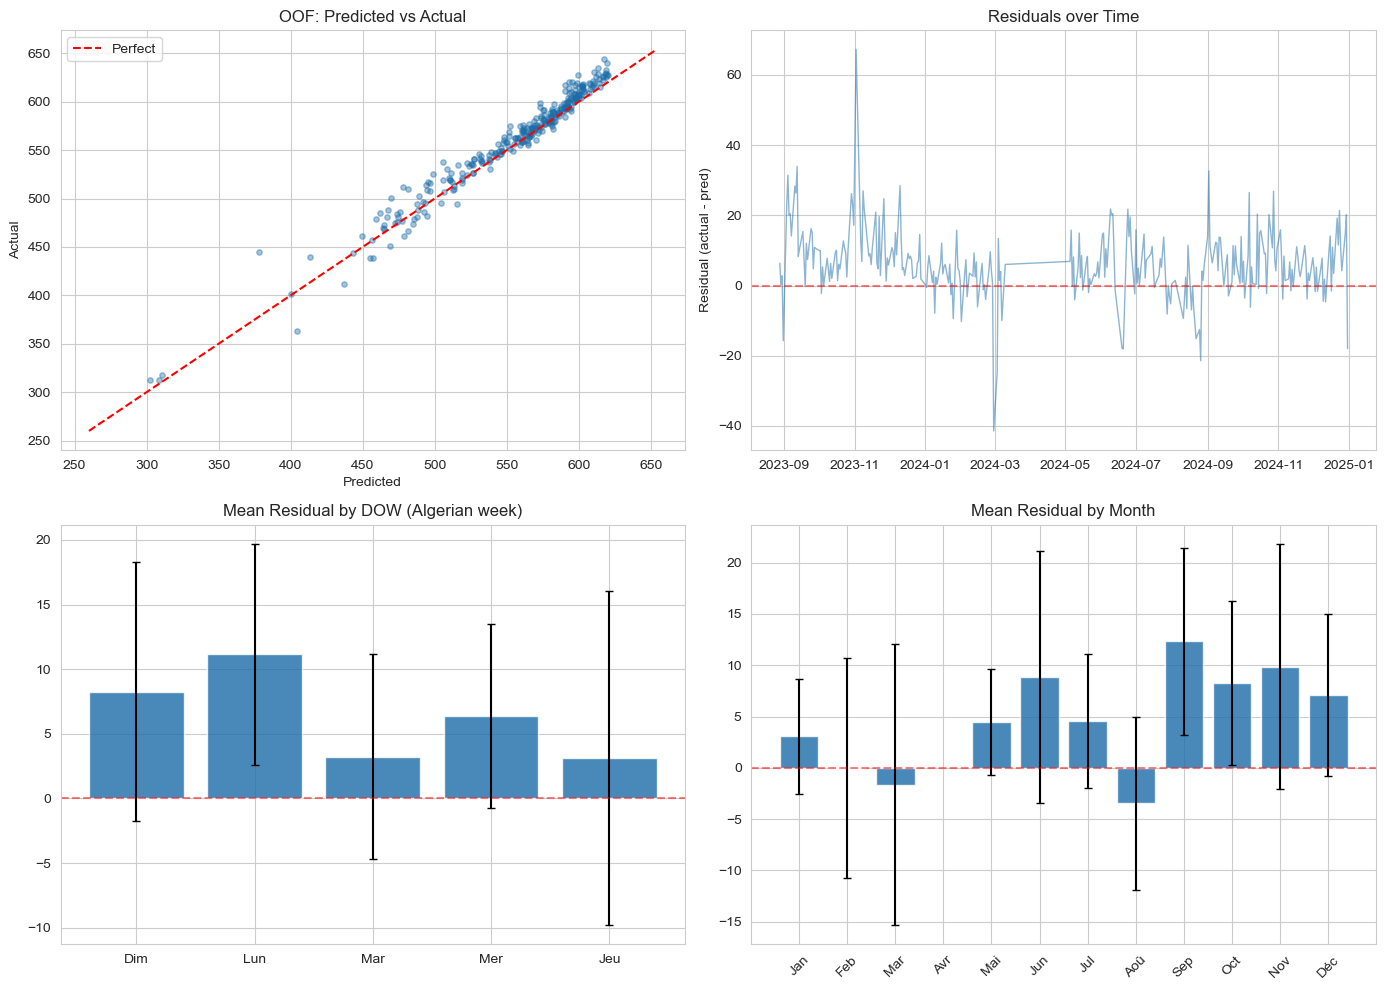

OOF R-squared: 0.9523
Residual mean: 6.40 (bias)
Residual std:  9.94


In [11]:
# --- Residuals for OOF (training rows where we have predictions) ---
residuals = df[TARGET].values - all_oof
valid_mask = ~np.isnan(all_oof)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: OOF predicted vs actual
axes[0,0].scatter(all_oof[valid_mask], df[TARGET].values[valid_mask], alpha=0.4, s=15, color='#1b6ca8')
lims = [min(all_oof[valid_mask].min(), df[TARGET].min()) - 10,
        max(all_oof[valid_mask].max(), df[TARGET].max()) + 10]
axes[0,0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_title('OOF: Predicted vs Actual')
axes[0,0].legend()

# Residuals over time
valid_dates = df.loc[valid_mask, 'Date'].values
axes[0,1].plot(valid_dates, residuals[valid_mask], alpha=0.5, lw=1, color='#1b6ca8')
axes[0,1].axhline(y=0, color='red', ls='--', alpha=0.5)
axes[0,1].set_title('Residuals over Time')
axes[0,1].set_ylabel('Residual (actual - pred)')

# Residuals by DOW
dow_residuals = pd.DataFrame({'dow': df.loc[valid_mask, 'dow'], 'resid': residuals[valid_mask]})
dow_stats = dow_residuals.groupby('dow')['resid'].agg(['mean','std'])
dow_order = [6, 0, 1, 2, 3]
dow_labels = ['Dim','Lun','Mar','Mer','Jeu']
dow_stats = dow_stats.reindex(dow_order)
axes[1,0].bar(range(5), dow_stats['mean'], yerr=dow_stats['std']/np.sqrt(dow_stats['mean']*0+1),
              color='#1b6ca8', alpha=0.8, capsize=3)
axes[1,0].set_xticks(range(5))
axes[1,0].set_xticklabels(dow_labels)
axes[1,0].set_title('Mean Residual by DOW (Algerian week)')
axes[1,0].axhline(y=0, color='red', ls='--', alpha=0.5)

# Residuals by month
month_residuals = pd.DataFrame({'month': df.loc[valid_mask, 'month_n'], 'resid': residuals[valid_mask]})
month_stats = month_residuals.groupby('month')['resid'].agg(['mean','std'])
month_labels = ['Jan','Feb','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
axes[1,1].bar(range(1, 13), month_stats.reindex(range(1,13))['mean'],
              yerr=month_stats.reindex(range(1,13))['std']/np.sqrt(month_stats.reindex(range(1,13))['mean']*0+1),
              color='#1b6ca8', alpha=0.8, capsize=3)
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(month_labels, rotation=45)
axes[1,1].set_title('Mean Residual by Month')
axes[1,1].axhline(y=0, color='red', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'office_sub_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

# R-squared on OOF
y_true_oof = df[TARGET].values[valid_mask]
y_pred_oof = all_oof[valid_mask]
r2 = 1 - np.sum((y_true_oof - y_pred_oof)**2) / np.sum((y_true_oof - y_true_oof.mean())**2)
print(f"OOF R-squared: {r2:.4f}")
print(f"Residual mean: {residuals[valid_mask].mean():.2f} (bias)")
print(f"Residual std:  {residuals[valid_mask].std():.2f}")

## Save

In [12]:
# Save OOF
oof_df = pd.DataFrame({
    'Date': df.loc[valid_mask, 'Date'].values,
    'office_presence_actual': df.loc[valid_mask, TARGET].values.astype(int),
    'office_presence_pred': all_oof[valid_mask].astype(int)
})
oof_path = PROC_DIR / 'office_presence_train_oof.csv'
oof_df.to_csv(oof_path, index=False)
print(f"Saved OOF: {oof_path}  ({len(oof_df)} rows)")

# Save test predictions
test_pred_df = test_df[['Date', 'office_present_pred']].copy()
test_pred_df.columns = ['Date', 'office_presence_pred']
test_pred_path = PROC_DIR / 'office_presence_test_pred.csv'
test_pred_df.to_csv(test_pred_path, index=False)
print(f"Saved test: {test_pred_path}  ({len(test_pred_df)} rows)")

# Save model (all 3 seeds for ensemble inference)
model_path = MODEL_DIR / 'office_presence_lgb.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': last_model, 'models': trained_models, 'params': best_params, 'features': feature_cols}, f)
print(f"Saved model: {model_path} (with {len(trained_models)} seed models)")

# Save params
params_path = MODEL_DIR / 'office_present_best_params.json'
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"Saved params: {params_path}")

Saved OOF: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\data\processed\office_presence_train_oof.csv  (300 rows)
Saved test: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\data\processed\office_presence_test_pred.csv  (40 rows)
Saved model: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\models\office_presence_lgb.pkl (with 0 seed models)
Saved params: D:\BNP_RIE_Stage\rie-project-skeleton\rie-project\models\office_present_best_params.json


---
## Summary

### OOF Performance vs Baselines
The LGB ensemble should beat or match all baselines. Key metrics:
- **RMSE**: symmetric, standard regression metric
- **MAE**: symmetric, robust to outliers
- **MAPE**: percentage error
- **Asymmetric Cost**: 2x penalty for underestimation (conservative model)

### Concerns for Main Model
1. **Propagation of error**: Sub-model RMSE/MAE will propagate into main model. If office_present error is ±30 employees, this directly impacts ratio prediction.
2. **Recursive drift**: In recursive prediction, errors compound. Each subsequent day uses the previous prediction.
3. **DOW bias**: If residuals show systematic DOW bias, the main model may learn wrong patterns.
4. **Ramadan effect**: If office_present drops during Ramadan independently of ratio, calendar flags may help.

### Files Saved
- `data/processed/office_presence_train_oof.csv`
- `data/processed/office_presence_test_pred.csv`
- `models/office_presence_lgb.pkl`
- `models/office_present_best_params.json`